In [1]:
# 0. CARGA DEL DATA SAMPLE PARA REPRODUCIBILIDAD
# -------------------------------------------------------------

import pandas as pd
import numpy as np

# Cargar el dataset de muestra
df = pd.read_parquet("src/correcciondef/data_sample/air_quality_sample.parquet")

df.head()

,Samplingpoint,Pollutant,Start,End,Value,Unit,AggType,Validity,Verification,ResultTime,DataCapture,FkObservationLog
0,ES/SP_41091016_10_49,5,2022-09-28 20:00:00,2022-09-28 21:00:00,44.690000000000000000,ug.m-3,hour,1,1,2023-07-09 19:16:00,None,324d40d7-9da8-4656-b5f4-1749dcdf2897
1,ES/SP_28079056_9_47,6001,2022-03-14 19:00:00,2022-03-14 20:00:00,10.000000000000000000,ug.m-3,hour,1,1,2023-07-09 20:30:00,None,865e265a-b481-45bd-a672-b9668c1d869c
2,ES/SP_28079058_14_6,7,2024-07-12 12:00:00,2024-07-12 13:00:00,134.000000000000000000,ug.m-3,hour,1,1,2025-06-19 17:46:00,None,07046feb-667e-4655-a32e-92fc0221af68
3,ES/SP_28074007_9_49,6001,2022-09-04 09:00:00,2022-09-04 10:00:00,7.000000000000000000,ug.m-3,hour,1,1,2023-07-09 20:29:00,None,a43ce98a-25f1-4415-8aa9-bac573de2db1
4,ES/SP_48902006_9_49,6001,2023-12-04 09:00:00,2023-12-04 10:00:00,1.000000000000000000,ug.m-3,hour,1,1,2024-08-02 10:44:00,None,2e105f1f-d0a9-4dfd-afec-aacb47c3a543


In [2]:
df.shape #Comprobación del tamaño del dataset

(5000, 12)

In [3]:
# 2. PREPROCESADO INICIAL: creación de fecha, mapeo de contaminantes y pivotado

# -------------------------------------------------------------
# 1) Crear columna de fecha a partir de 'Start'
# -------------------------------------------------------------

# Convertimos la columna Start a tipo datetime
df["Fecha"] = pd.to_datetime(df["Start"])

# Mostramos las primeras filas para comprobar
df[["Start", "Fecha"]].head()

,Start,Fecha
0,2022-09-28 20:00:00,2022-09-28 20:00:00
1,2022-03-14 19:00:00,2022-03-14 19:00:00
2,2024-07-12 12:00:00,2024-07-12 12:00:00
3,2022-09-04 09:00:00,2022-09-04 09:00:00
4,2023-12-04 09:00:00,2023-12-04 09:00:00


In [4]:
# -------------------------------------------------------------
# 2) Mapear códigos de contaminantes a nombres reales
# -------------------------------------------------------------

# Diccionario oficial de códigos EEA
mapa_contaminantes = {
    5: "PM10",
    6001: "PM25",
    8: "NO2",
    7: "O3"
}

# Creamos una nueva columna con el nombre del contaminante
df["Contaminante"] = df["Pollutant"].map(mapa_contaminantes)

# Comprobamos que se ha creado correctamente
df[["Pollutant", "Contaminante"]].head()

,Pollutant,Contaminante
0,5,PM10
1,6001,PM25
2,7,O3
3,6001,PM25
4,6001,PM25


In [5]:
df["Pollutant"].unique() # Comprobamos que solo tenemos los contaminantes esperados
# El dataset contiene códigos oficiales de la Agencia Europea de Medio Ambiente (EEA) para los contaminantes PM10, PM2.5, NO2 y O3. El mapeo ha funcionado correctamente.


array([   5, 6001,    7,    8], dtype=int32)

In [6]:
df["Contaminante"].unique() # Comprobamos que el mapeo ha funcionado

array(['PM10', 'PM25', 'O3', 'NO2'], dtype=object)

In [7]:
# -------------------------------------------------------------
# 3) Pivotar contaminantes para tener columnas PM10, PM25, NO2, O3 
# (pasar de formato largo a ancho)
# -------------------------------------------------------------

df_pivot = df.pivot_table(
    index=["Samplingpoint", "Fecha"],   # agrupamos por estación y fecha
    columns="Contaminante",            # cada contaminante será una columna
    values="Value"                     # valores medidos
).reset_index()

# Mostramos el resultado
df_pivot.head()

Contaminante,Samplingpoint,Fecha,NO2,O3,PM10,PM25
0,ES/SP_06015001_14_6,2022-02-22 08:00:00,NaN,6.1,NaN,NaN
1,ES/SP_06015001_14_6,2022-06-07 12:00:00,NaN,60.0,NaN,NaN
2,ES/SP_06015001_14_6,2022-07-07 09:00:00,NaN,89.0,NaN,NaN
3,ES/SP_06015001_14_6,2022-10-18 23:00:00,NaN,60.0,NaN,NaN
4,ES/SP_06015001_14_6,2022-11-09 03:00:00,NaN,40.0,NaN,NaN


In [8]:
# -------------------------------------------------------------
# Comprobación adicional: número de registros por contaminante
# -------------------------------------------------------------
# Tras el pivotado, 'Contaminante' ya no es una columna.
# Por eso comprobamos directamente las columnas PM10, PM25, NO2 y O3.
# Esto permite verificar si algún contaminante tiene muy pocos datos

df_pivot[["PM10", "PM25", "NO2", "O3"]].count()

Contaminante
PM10    1046
PM25     689
NO2     1962
O3      1303
dtype: int64

In [9]:
# -------------------------------------------------------------
# 4) Ordenar por fecha 
# -------------------------------------------------------------

df_pivot = df_pivot.sort_values("Fecha")
df_pivot.head()

Contaminante,Samplingpoint,Fecha,NO2,O3,PM10,PM25
900,ES/SP_08301004_8_8,2022-01-01 01:00:00,31.0,NaN,NaN,NaN
2699,ES/SP_28079060_14_6,2022-01-01 02:00:00,NaN,7.25,NaN,NaN
3421,ES/SP_41091019_14_6,2022-01-01 08:00:00,NaN,18.0,NaN,NaN
4633,ES/SP_48020062_8_8,2022-01-01 14:00:00,9.0,NaN,NaN,NaN
1163,ES/SP_28058004_10_49,2022-01-01 15:00:00,NaN,NaN,6.0,NaN


In [10]:
# 3. INTEGRACIÓN POR CIUDAD: unificar estaciones

# -------------------------------------------------------------
# 3.1. Asignación automática de ciudad según el prefijo del código de estación
# -------------------------------------------------------------

def asignar_ciudad(codigo):
    if codigo.startswith("ES/SP_060"):
        return "Badajoz"
    if codigo.startswith("ES/SP_280"):
        return "Madrid"
    if codigo.startswith("ES/SP_462"):
        return "Valencia"
    if codigo.startswith("ES/SP_480"):
        return "Bilbao"
    if codigo.startswith("ES/SP_410"):
        return "Sevilla"
    if codigo.startswith("ES/SP_08"):   # incluye 080, 081, 082, 083
        return "Barcelona"  # por si aparece algo raro
    return None

# Aplicar la función para crear la columna Ciudad
df_pivot["Ciudad"] = df_pivot["Samplingpoint"].apply(asignar_ciudad)
df_pivot[["Samplingpoint", "Ciudad"]].head()


Contaminante,Samplingpoint,Ciudad
900,ES/SP_08301004_8_8,Barcelona
2699,ES/SP_28079060_14_6,Madrid
3421,ES/SP_41091019_14_6,Sevilla
4633,ES/SP_48020062_8_8,Bilbao
1163,ES/SP_28058004_10_49,Madrid


In [11]:
# -------------------------------------------------------------
# 3.2. Reordenar columnas para mayor claridad
# -------------------------------------------------------------
# Después de asignar la ciudad, queremos que el DataFrame tenga
# un orden lógico y fácil de leer:
#   1) Ciudad
#   2) Código de estación
#   3) Fecha completa (con hora)
#   4) Contaminantes ya pivotados
#
# Esto NO modifica datos, solo cambia el orden visual de columnas.

df_pivot = df_pivot[[
    "Ciudad",          # Ciudad asignada automáticamente
    "Samplingpoint",   # Código de estación original
    "Fecha",           # Fecha y hora de la medición
    "PM10", "PM25",    # Partículas
    "NO2", "O3"        # Gases
]]

# Vista rápida para confirmar que el orden es correcto
df_pivot.head()

Contaminante,Ciudad,Samplingpoint,Fecha,PM10,PM25,NO2,O3
900,Barcelona,ES/SP_08301004_8_8,2022-01-01 01:00:00,NaN,NaN,31.0,NaN
2699,Madrid,ES/SP_28079060_14_6,2022-01-01 02:00:00,NaN,NaN,NaN,7.25
3421,Sevilla,ES/SP_41091019_14_6,2022-01-01 08:00:00,NaN,NaN,NaN,18.0
4633,Bilbao,ES/SP_48020062_8_8,2022-01-01 14:00:00,NaN,NaN,9.0,NaN
1163,Madrid,ES/SP_28058004_10_49,2022-01-01 15:00:00,6.0,NaN,NaN,NaN


In [12]:
# -------------------------------------------------------------
# 3.3. Crear fecha diaria (sin hora)
# -------------------------------------------------------------
# La columna 'Fecha' contiene fecha y hora (ej: 2023-01-01 13:00)
# Para obtener medias diarias necesitamos una fecha sin hora.
# .dt.date extrae solo la parte de fecha (YYYY-MM-DD)

df_pivot["Fecha_dia"] = df_pivot["Fecha"].dt.date

# Comprobación rápida
df_pivot[["Fecha", "Fecha_dia"]].head()


Contaminante,Fecha,Fecha_dia
900,2022-01-01 01:00:00,2022-01-01
2699,2022-01-01 02:00:00,2022-01-01
3421,2022-01-01 08:00:00,2022-01-01
4633,2022-01-01 14:00:00,2022-01-01
1163,2022-01-01 15:00:00,2022-01-01


In [13]:
# -------------------------------------------------------------
# 3.4. Agrupar por ciudad y día (media diaria de contaminantes)
# -------------------------------------------------------------

# Calcular la media diaria por ciudad
df_ciudad = (
    df_pivot
    .groupby(["Ciudad", "Fecha_dia"])[["PM10", "PM25", "NO2", "O3"]]
    .mean()
    .reset_index()
)

# Vista rápida del resultado
df_ciudad.head()

Contaminante,Ciudad,Fecha_dia,PM10,PM25,NO2,O3
0,Badajoz,2022-01-11,NaN,NaN,9.4,NaN
1,Badajoz,2022-01-31,NaN,NaN,49.0,NaN
2,Badajoz,2022-02-22,NaN,NaN,NaN,6.1
3,Badajoz,2022-05-14,NaN,NaN,10.0,NaN
4,Badajoz,2022-06-07,NaN,NaN,NaN,60.0


In [14]:
# 4. DIVISIÓN TRAIN/TEST antes de cualquier limpieza o transformación.

# En este paso realizamos el split del dataset antes de aplicar cualquier limpieza, interpolación o escalado.
# Esto evita que el modelo "vea" información del conjunto de test durante el preprocesado (data leakage).
# División del dataset crudo pero ya integrado.
# No se limpia, no se interpola y no se escalan aún.

from sklearn.model_selection import train_test_split

# División del dataset en entrenamiento y prueba
# Estratificamos por ciudad para mantener proporciones similares
train_df, test_df = train_test_split(
    df_ciudad,
    test_size=0.2,
    random_state=42,
    stratify=df_ciudad["Ciudad"]
)

print("Tamaño del conjunto de entrenamiento:", train_df.shape)
print("Tamaño del conjunto de prueba:", test_df.shape)

Tamaño del conjunto de entrenamiento: (2371, 6)
Tamaño del conjunto de prueba: (593, 6)


In [15]:
# 5. FEATURE ENGINEERING (mes, estación del año, tendencias, etc.)

# En este apartado creamos nuevas variables temporales y derivadas 
# que enriquecen el dataset para análisis, clustering y regresión.

# Crear copias de train y test para el feature engineering
train_feat = train_df.copy()
test_feat  = test_df.copy()

In [16]:
import numpy as np

# -------------------------------------------------------------
# 5.0. Limpieza mínima necesaria para Feature Engineering
# -------------------------------------------------------------

cols_contam = ["PM10", "PM25", "NO2", "O3"]

# 1) Limpiar strings problemáticos ANTES de convertir a float
for c in cols_contam:
    train_feat[c] = (
        train_feat[c]
        .astype(str)
        .str.replace(",", ".", regex=False)              # cambiar coma por punto
        .str.replace(r"[^0-9\.\-]", "", regex=True)      # eliminar caracteres raros
        .str.strip()                                     # quitar espacios
        .replace(["", " ", "None", "nan", "NaN", "--", "-", "."], np.nan)
    )
    
    test_feat[c] = (
        test_feat[c]
        .astype(str)
        .str.replace(",", ".", regex=False)
        .str.replace(r"[^0-9\.\-]", "", regex=True)
        .str.strip()
        .replace(["", " ", "None", "nan", "NaN", "--", "-", "."], np.nan)
    )

# 2) Convertir a float (forzando dtype correcto)
for c in cols_contam:
    train_feat[c] = train_feat[c].astype(float)
    test_feat[c]  = test_feat[c].astype(float)

# 3) Convertir Fecha_dia a datetime
train_feat["Fecha_dia"] = pd.to_datetime(train_feat["Fecha_dia"])
test_feat["Fecha_dia"]  = pd.to_datetime(test_feat["Fecha_dia"])

# 4) Ordenar por ciudad y fecha (necesario para rolling, lag, diff, cumsum)
train_feat = train_feat.sort_values(["Ciudad", "Fecha_dia"])
test_feat  = test_feat.sort_values(["Ciudad", "Fecha_dia"])

In [17]:
# -------------------------------------------------------------
# 5.1. INTERPOLACIÓN POR CIUDAD (TRAIN y TEST)
# -------------------------------------------------------------
# En este paso reparamos los huecos en las series temporales.
# La interpolación lineal por ciudad es fundamental para:
#   - evitar NaNs en rolling, lag, diff, cumsum
#   - suavizar la serie
#   - obtener un dataset consistente para modelado

train_feat[cols_contam] = (
    train_feat.groupby("Ciudad")[cols_contam]
    .apply(lambda g: g.interpolate(method="linear", limit_direction="both"))
    .reset_index(level=0, drop=True)
)

test_feat[cols_contam] = (
    test_feat.groupby("Ciudad")[cols_contam]
    .apply(lambda g: g.interpolate(method="linear", limit_direction="both"))
    .reset_index(level=0, drop=True)
)

In [18]:
# -------------------------------------------------------------
# 5.2. ELIMINACIÓN DE OUTLIERS (IQR) — SOLO EN TRAIN
# -------------------------------------------------------------
# Eliminamos valores extremos que distorsionan:
#   - rolling
#   - lag
#   - diff
#   - clustering
#   - regresión
#
# El test NO se toca para no introducir data leakage.

def marcar_outliers_iqr(serie):
    Q1 = serie.quantile(0.25)
    Q3 = serie.quantile(0.75)
    IQR = Q3 - Q1
    lim_inf = Q1 - 1.5 * IQR
    lim_sup = Q3 + 1.5 * IQR
    return (serie < lim_inf) | (serie > lim_sup)

# Crear columnas de outliers
for c in cols_contam:
    train_feat[f"{c}_outlier"] = marcar_outliers_iqr(train_feat[c])

# Fila marcada como outlier si CUALQUIER contaminante lo es
mask_out = train_feat[[f"{c}_outlier" for c in cols_contam]].any(axis=1)

# Dataset limpio final
train_feat = train_feat.loc[~mask_out].copy()

In [19]:
# -------------------------------------------------------------
# 5.3. FEATURE ENGINEERING COMPLETO (TRAIN y TEST)
# -------------------------------------------------------------
# Aquí creamos todas las variables derivadas:
#   - Año, Mes, Día, Día_semana, Semana_año
#   - Estación del año
#   - Tendencia acumulada (cumsum)
#   - Media móvil (rolling 7 días)
#   - Rezagos (lag1)
#   - Diferencias (diff)

# Estas variables enriquecen el dataset para análisis, clustering y regresión.

# 5.3.1 Variables temporales
for df_ in [train_feat, test_feat]:
    df_["Año"] = df_["Fecha_dia"].dt.year
    df_["Mes"] = df_["Fecha_dia"].dt.month
    df_["Día"] = df_["Fecha_dia"].dt.day
    df_["Día_semana"] = df_["Fecha_dia"].dt.weekday
    df_["Semana_año"] = df_["Fecha_dia"].dt.isocalendar().week.astype(int)

In [20]:
# 5.3.2 Estación del año

def estacion_del_año(mes):
    if mes in [12, 1, 2]:
        return "Invierno"
    elif mes in [3, 4, 5]:
        return "Primavera"
    elif mes in [6, 7, 8]:
        return "Verano"
    else:
        return "Otoño"

train_feat["Estacion"] = train_feat["Mes"].apply(estacion_del_año)
test_feat["Estacion"]  = test_feat["Mes"].apply(estacion_del_año)

In [21]:
# 5.3.3 Tendencia acumulada (cumsum)
# Captura la evolución a largo plazo de cada contaminante.

for c in cols_contam:
    train_feat[f"{c}_cumsum"] = train_feat.groupby("Ciudad")[c].cumsum()
    test_feat[f"{c}_cumsum"]  = test_feat.groupby("Ciudad")[c].cumsum()

In [22]:
# 5.3.4 Media móvil (rolling 7 días)
# Suaviza la serie y captura tendencias a corto plazo.

for c in cols_contam:
    train_feat[f"{c}_roll7"] = train_feat.groupby("Ciudad")[c].transform(
        lambda x: x.rolling(7, min_periods=1).mean()
    )
    test_feat[f"{c}_roll7"] = test_feat.groupby("Ciudad")[c].transform(
        lambda x: x.rolling(7, min_periods=1).mean()
    )

In [23]:
# 5.3.5 Rezagos (lag 1)
# Captura el valor del día anterior.

for c in cols_contam:
    train_feat[f"{c}_lag1"] = train_feat.groupby("Ciudad")[c].shift(1)
    test_feat[f"{c}_lag1"]  = test_feat.groupby("Ciudad")[c].shift(1)

In [24]:
# 5.3.6 Diferencias (diff)
# Captura cambios bruscos entre días consecutivos.

for c in cols_contam:
    train_feat[f"{c}_diff"] = train_feat.groupby("Ciudad")[c].diff()
    test_feat[f"{c}_diff"]  = test_feat.groupby("Ciudad")[c].diff()


In [25]:
# 6. GUARDADO DE DATASETS FINALES (TRAIN Y TEST)

# En este apartado guardamos los datasets finales ya:
#    - limpios
#    - interpolados
#    - sin outliers (solo TRAIN)
#    - y con todas las variables derivadas (Feature Engineering aplicado).

# Estos archivos son la versión final del dataset y pueden usarse directamente para modelado sin repetir el pipeline.

# Guardar en formato Parquet (recomendado: más rápido y eficiente)
train_feat.to_parquet("src/correcciondef/data/train_final.parquet", index=False)
test_feat.to_parquet("src/correcciondef/data/test_final.parquet", index=False)

# Opcional: guardar también en CSV
train_feat.to_csv("src/correcciondef/data/train_final.csv", index=False)
test_feat.to_csv("src/correcciondef/data/test_final.csv", index=False)

print("Datasets finales guardados correctamente.")

Datasets finales guardados correctamente.


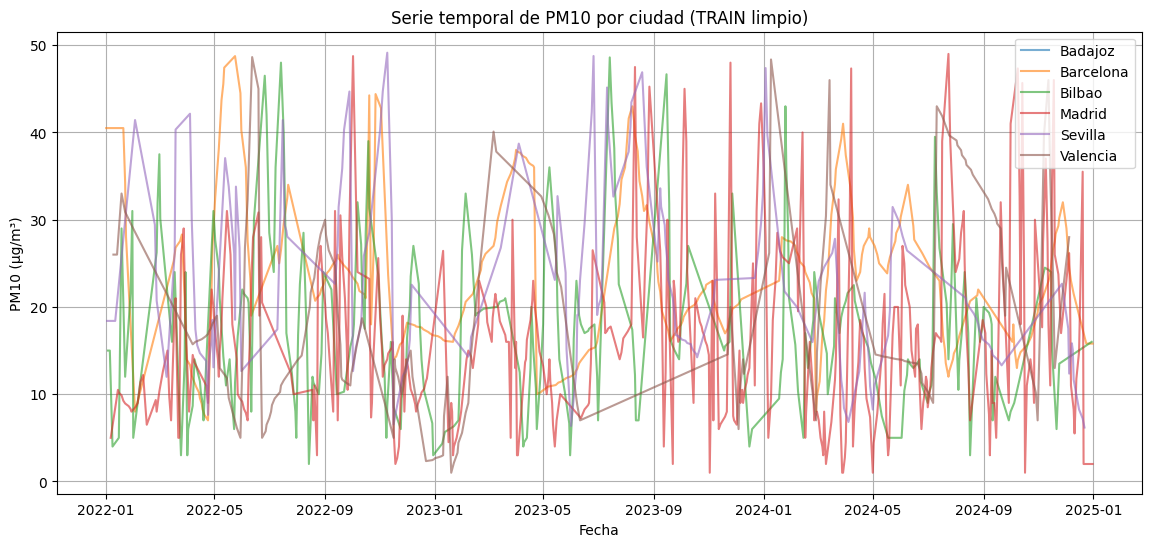

In [26]:
# 7. MINI‑EDA (Análisis Exploratorio de Datos)

# El MINI‑EDA debe hacerse sobre train_feat, porque:
#   - El EDA siempre se hace solo con TRAIN para evitar data leakage.
#   - El TEST debe permanecer “virgen” hasta la evaluación del modelo, 
#     para que el test final sea una evaluación realista de la capacidad de generalización del modelo a datos nuevos.

# -------------------------------------------------------------
# 7.1. MINI-EDA:Serie temporal de PM10 por ciudad
# -------------------------------------------------------------

import matplotlib.pyplot as plt
import matplotlib as mpl

# Este gráfico permite visualizar la evolución del PM10 a lo largo del tiempo.
# Es fundamental para detectar tendencias, estacionalidad, picos y anomalías.
# Además, justifica la creación de variables lag y diff en el preprocesado.

# Filtramos solo PM10 del TRAIN
df_pm10 = train_feat[["Ciudad", "Fecha_dia", "PM10"]].copy()

# Evitar overflow con muchas líneas
mpl.rcParams['agg.path.chunksize'] = 10000

plt.figure(figsize=(14,6))

# Recorremos cada ciudad del TRAIN limpio
for ciudad in df_pm10["Ciudad"].unique():
    df_c = df_pm10[df_pm10["Ciudad"] == ciudad]
    plt.plot(df_c["Fecha_dia"], df_c["PM10"], alpha=0.6, label=ciudad)

plt.title("Serie temporal de PM10 por ciudad (TRAIN limpio)")
plt.xlabel("Fecha")
plt.ylabel("PM10 (µg/m³)")
plt.legend()
plt.grid(True)

plt.savefig("src/correcciondef/img/serie_temporal_pm10.png", dpi=300, bbox_inches="tight")
plt.show()

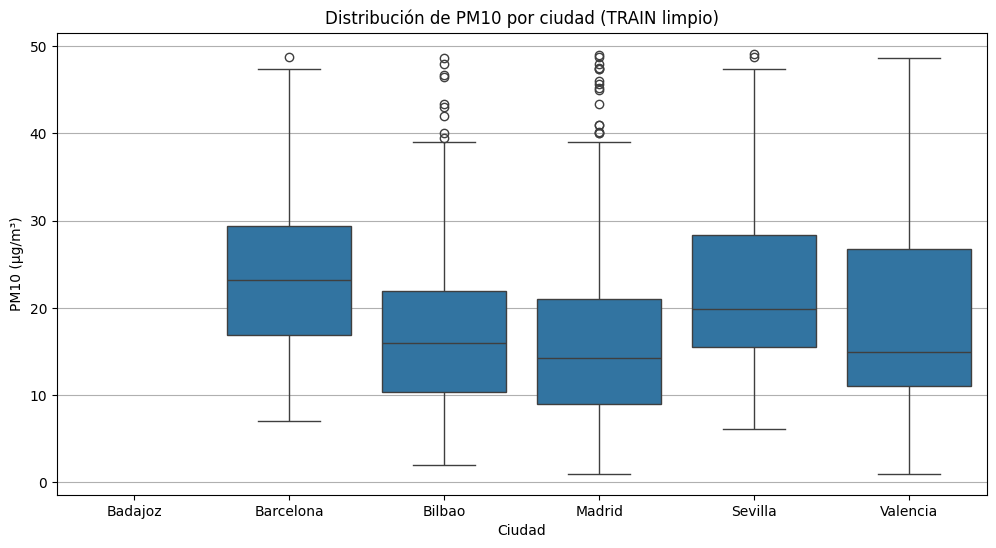

In [27]:
# -------------------------------------------------------------
# 7.2. MINI‑EDA: Boxplot de PM10 por ciudad
# -------------------------------------------------------------

import seaborn as sns

# Boxplot con seaborn (NO pandas)

# Este boxplot permite comparar la distribución del PM10 entre ciudades.
# Ayuda a identificar ciudades con niveles más altos o más variables.
# También permite detectar outliers y diferencias estructurales entre zonas.

plt.figure(figsize=(12,6))
sns.boxplot(data=df_pm10, x="Ciudad", y="PM10")
plt.title("Distribución de PM10 por ciudad (TRAIN limpio)")
plt.xlabel("Ciudad")
plt.ylabel("PM10 (µg/m³)")
plt.grid(True, axis='y')

plt.savefig("src/correcciondef/img/boxplot_pm10_ciudad.png", dpi=300, bbox_inches="tight")
plt.show()

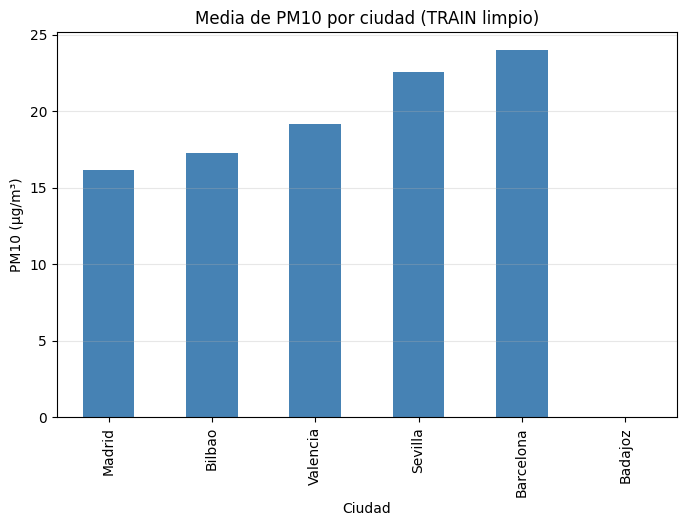

In [28]:
# -------------------------------------------------------------
# 7.3. MINI‑EDA: Gráfico de barras
# -------------------------------------------------------------

# Nos ayuda a realizar la comparación entre ciudades.
# Usamos df_pm10 porque ya contiene solo Ciudad, Fecha_dia y PM10 del TRAIN.

import matplotlib.pyplot as plt

# Calcular la media de PM10 por ciudad usando TRAIN limpio
media_pm10 = df_pm10.groupby("Ciudad")["PM10"].mean().sort_values()

# Gráfico de barras
plt.figure(figsize=(8,5))
media_pm10.plot(kind="bar", color="steelblue")

plt.title("Media de PM10 por ciudad (TRAIN limpio)")
plt.ylabel("PM10 (µg/m³)")
plt.xlabel("Ciudad")
plt.grid(axis="y", alpha=0.3)

# Guardar imagen
plt.savefig("src/correcciondef/img/media_pm10_por_ciudad.png", dpi=300, bbox_inches="tight")
plt.show()

In [29]:
# Verificar si Badajoz tiene datos de PM10

df_pm10.groupby("Ciudad")["PM10"].count() # Muestra cuántos registros tiene cada ciudad.

Ciudad
Badajoz        0
Barcelona    346
Bilbao       292
Madrid       521
Sevilla      187
Valencia     171
Name: PM10, dtype: int64

Se comprueba que Badajoz no tiene datos de PM10 en el dataframe df_pm10.

In [30]:
# Comprobar que Badajoz aparece en df_pm10

df_pm10["Ciudad"].unique()

array(['Badajoz', 'Barcelona', 'Bilbao', 'Madrid', 'Sevilla', 'Valencia'],
      dtype=object)

Como Badajoz sí aparece en el df, entonces el problema está en los valores de PM10 (todos nulos o inexistentes).

In [31]:
# Ver cuántos registros tiene Badajoz

df_pm10[df_pm10["Ciudad"] == "Badajoz"].shape # Muestra el número de filas y columnas que hay para Badajoz. 
#Si es 0, no hay datos. Si es > 0, sí hay datos.

(32, 3)

In [32]:
# Ver si Badajoz tiene valores de PM10

df_pm10[df_pm10["Ciudad"] == "Badajoz"]["PM10"].describe()

count    0.0
mean     NaN
std      NaN
min      NaN
25%      NaN
50%      NaN
75%      NaN
max      NaN
Name: PM10, dtype: float64

Badajoz si tiene filas en df_pm10 (33 filas), pero no existe ningún dato de PM10 para Badajoz en tu dataset, al menos en el periodo analizado. Puede ocurrir porque la estación de Badajoz no reporte PM10 (algunas estaciones de España reportan solo determinados contaminantes).

In [33]:
df_pm10[df_pm10["Ciudad"] == "Badajoz"]["PM10"].isna().sum()

np.int64(32)

In [34]:
# Comprobar si Badajoz tiene otros contaminantes

train_feat[train_feat["Ciudad"] == "Badajoz"][["PM25", "NO2", "O3"]].count()

Contaminante
PM25     0
NO2     32
O3      32
dtype: int64

Las estaciones de Badajoz solo reportan NO₂ y O₃ en tu dataset. No reportan PM10 ni PM2.5.

Esto es completamente normal en datos reales de calidad del aire, ya que muchas estaciones españolas no miden todos los contaminantes.

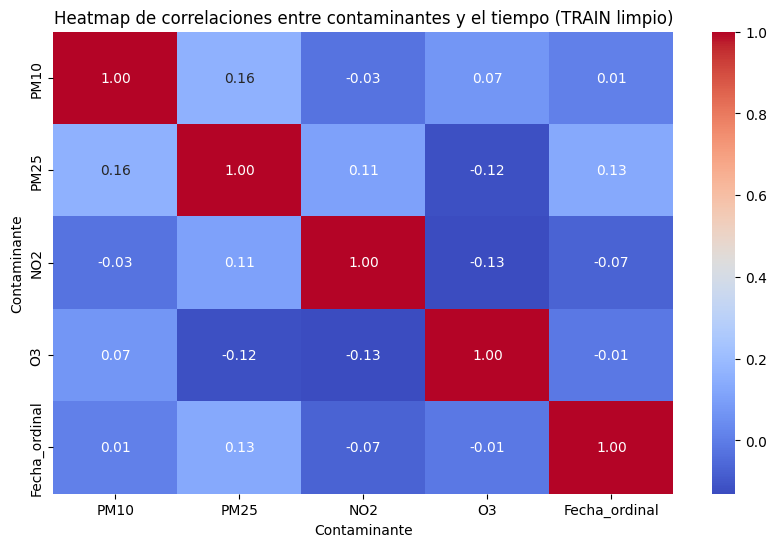

In [35]:
# -------------------------------------------------------------------
# 7.4. MINI‑EDA: Heatmap de correlaciones (TRAIN limpio)
# -------------------------------------------------------------------

# Este heatmap permite visualizar la relación entre variables numéricas.
# Ayuda a identificar correlaciones relevantes para el modelado.
# También permite detectar multicolinealidad entre features.

import seaborn as sns
import matplotlib.pyplot as plt

# Copia del dataset limpio
df_corr = train_feat.copy()

# Convertimos la fecha a número para poder correlacionarla
df_corr["Fecha_ordinal"] = df_corr["Fecha_dia"].map(lambda x: x.toordinal())

# Seleccionamos solo columnas numéricas relevantes
cols = ["PM10", "PM25", "NO2", "O3", "Fecha_ordinal"]

# Calculamos la matriz de correlación
corr = df_corr[cols].corr()

# Dibujamos el heatmap
plt.figure(figsize=(10,6))
sns.heatmap(corr, annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Heatmap de correlaciones entre contaminantes y el tiempo (TRAIN limpio)")
plt.savefig("src/correcciondef/img/heatmap_correlacion.png", dpi=300, bbox_inches="tight")
plt.show()

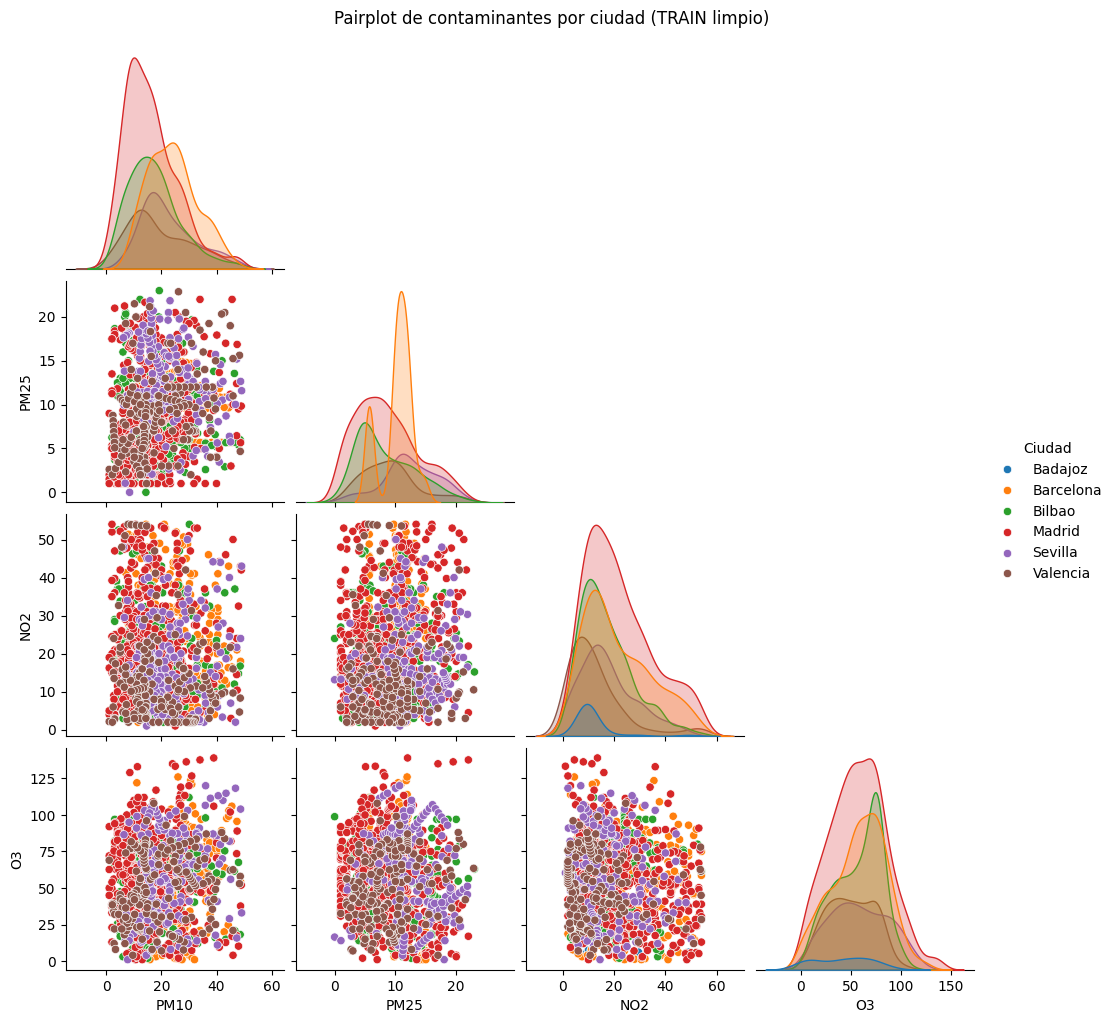

In [36]:
# -------------------------------------------------------------
# 7.5. MINI‑EDA: Pairplot de contaminantes
# -------------------------------------------------------------

# Este pairplot permite visualizar la relación entre cada par de contaminantes (PM10, PM25, NO2, O3) y cómo varían entre ciudades.
# Este gráfico tambien muestra:
#   - si hay correlaciones no lineales entre contaminantes
#   - si hay cluster visuales
#   - si hay dispersiones distintas por ciudad.

# Es fundamental para detectar patrones conjuntos entre contaminantes, diferencias estructurales entre ciudades y justificar la creación de variables lag y diff en el preprocesado.
# Es muy útil para justificar el clustering y la regresión, ya que muestra visualmente cómo se relacionan los contaminantes entre sí y con la ciudad.

import seaborn as sns
import matplotlib.pyplot as plt

# Seleccionamos solo columnas relevantes
df_pair = train_feat[["Ciudad", "PM10", "PM25", "NO2", "O3"]].copy()

# Pairplot coloreado por ciudad
sns.pairplot(df_pair, hue="Ciudad", diag_kind="kde", corner=True)

plt.suptitle("Pairplot de contaminantes por ciudad (TRAIN limpio)", y=1.02)
plt.savefig("src/correcciondef/img/pairplot_contaminantes.png", dpi=300, bbox_inches="tight")
plt.show()

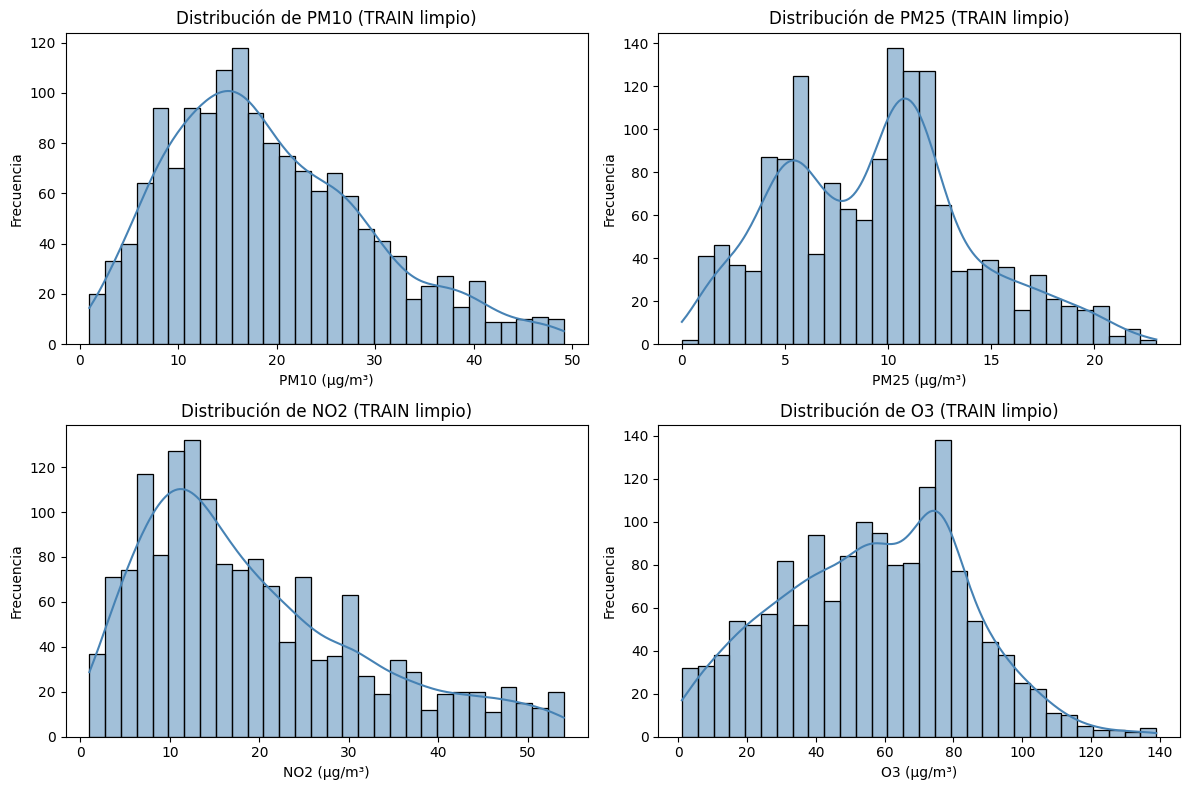

In [37]:
# -------------------------------------------------------------------------------
# 7.6. MINI‑EDA: Distribución individual de cada contaminante (histogramas + KDE)
# -------------------------------------------------------------------------------

# Nos permite ver:
#   - la forma de la distribución de cada contaminante (si tienen colsa largas, etc.)
#   - si hay sesgos o asimetrías en la distribución (skewness)
#   - si la distribución es normal, lognormal o bimodal

# Justifica transformaciones futuras (log, boxcox, etc.)

import seaborn as sns
import matplotlib.pyplot as plt

contaminantes = ["PM10", "PM25", "NO2", "O3"]

plt.figure(figsize=(12,8))

for i, c in enumerate(contaminantes, 1):
    plt.subplot(2, 2, i)
    sns.histplot(train_feat[c], kde=True, bins=30, color="steelblue")
    plt.title(f"Distribución de {c} (TRAIN limpio)")
    plt.xlabel(f"{c} (µg/m³)")
    plt.ylabel("Frecuencia")

plt.tight_layout()
plt.savefig("src/correcciondef/img/distribucion_contaminantes.png", dpi=300, bbox_inches="tight")
plt.show()

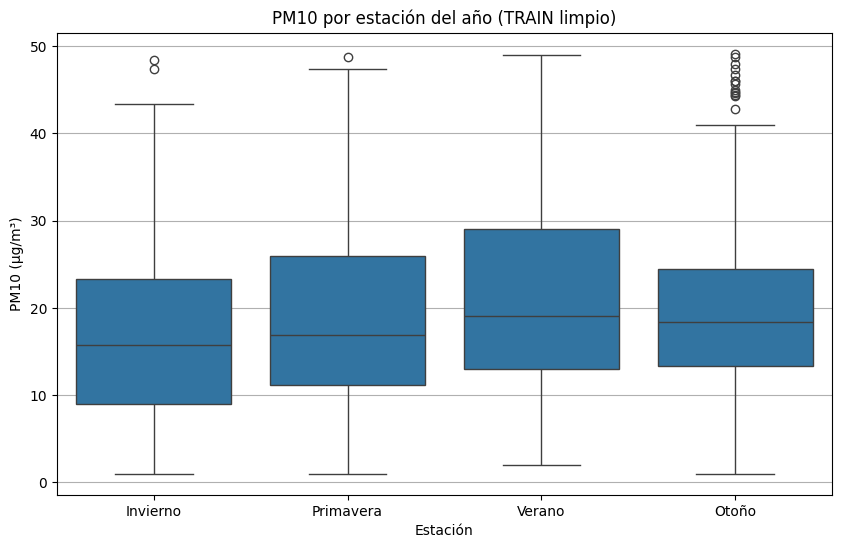

In [38]:
# -------------------------------------------------------------
# 7.7. MINI‑EDA: Boxplot de PM10 por estación del año
# -------------------------------------------------------------

# Este boxplot permite comparar la distribución del PM10 entre estaciones del año.
# También nos permite ver si cada ciudad tiene estacionalidad distinta.
# Ayuda a identificar si hay estacionalidad en el PM10, es decir, si ciertas estaciones tienen niveles más altos o más variables.

plt.figure(figsize=(10,6))
sns.boxplot(data=train_feat, x="Estacion", y="PM10", order=["Invierno","Primavera","Verano","Otoño"])
plt.title("PM10 por estación del año (TRAIN limpio)")
plt.xlabel("Estación")
plt.ylabel("PM10 (µg/m³)")
plt.grid(True, axis="y")

plt.savefig("src/correcciondef/img/pm10_por_estacion.png", dpi=300, bbox_inches="tight")
plt.show()

In [39]:
# 8. PREPARACIÓN DEL DATASET PARA CLUSTERING Y REGRESIÓN

# Partimos del dataset enriquecido: train_feat
# En este punto:
#   - Seleccionamos variables relevantes
#   - Codificamos variables categóricas
#   - Escalamos características numéricas
#   - Creamos dataset para clustering (solo TRAIN)
#   - Creamos dataset para regresión (solo TRAIN)

from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split

In [40]:
# -------------------------------------------------------------
# 8.1. CLUSTERING AVANZADO (con lag, diff, rolling, cumsum)
# -------------------------------------------------------------

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt

In [41]:
# -------------------------------------------------------------
# 8.1.1. Selección de features para clustering
# -------------------------------------------------------------

cols_cluster = [
    # Niveles absolutos
    "PM10", "PM25", "NO2", "O3",

    # Tendencia acumulada
    "PM10_cumsum", "PM25_cumsum", "NO2_cumsum", "O3_cumsum",

    # Cambios diarios
    "PM10_diff", "PM25_diff", "NO2_diff", "O3_diff",

    # Memoria de 1 día
    "PM10_lag1", "PM25_lag1", "NO2_lag1", "O3_lag1",

    # Suavizado (roll7, que sí existe en tu pipeline)
    "PM10_roll7", "PM25_roll7", "NO2_roll7", "O3_roll7"
]

df_cluster = train_feat[cols_cluster].copy()

In [42]:
[col for col in train_feat.columns if "cumsum" in col.lower()]

['PM10_cumsum', 'PM25_cumsum', 'NO2_cumsum', 'O3_cumsum']

In [43]:
# -------------------------------------------------------------
# 8.1.2. Relleno de NaNs (lag/diff/rolling generan NaNs)
# -------------------------------------------------------------

df_cluster = df_cluster.fillna(0)

In [44]:
# -------------------------------------------------------------
# 8.1.3. Escalado
# -------------------------------------------------------------

scaler_cluster = StandardScaler()
X_cluster = scaler_cluster.fit_transform(df_cluster)

In [45]:
# -------------------------------------------------------------
# 8.1.4. KMeans (se puede cambiar n_clusters)
# -------------------------------------------------------------

kmeans = KMeans(n_clusters=4, random_state=42)
labels = kmeans.fit_predict(X_cluster)

df_cluster["cluster"] = labels

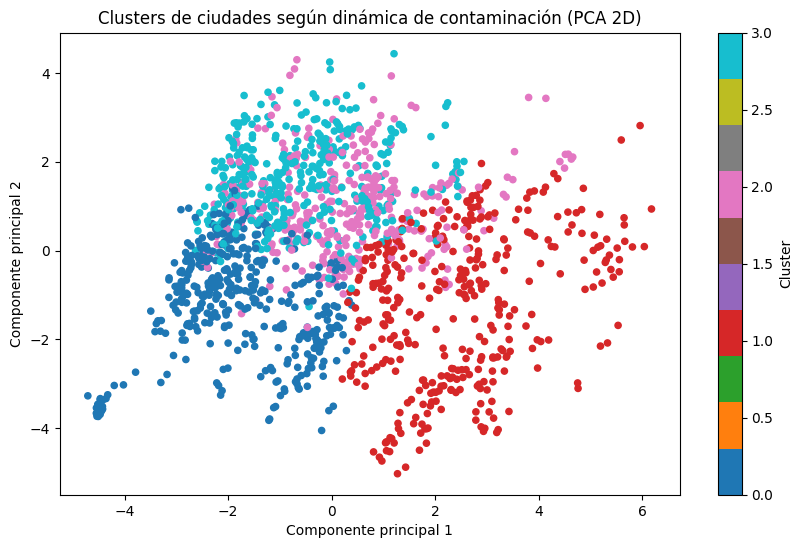

In [46]:
# -------------------------------------------------------------
# 8.1.5. Visualización con PCA (2D)
# -------------------------------------------------------------

pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_cluster)

plt.figure(figsize=(10,6))
plt.scatter(X_pca[:,0], X_pca[:,1], c=labels, cmap="tab10", s=20)
plt.title("Clusters de ciudades según dinámica de contaminación (PCA 2D)")
plt.xlabel("Componente principal 1")
plt.ylabel("Componente principal 2")
plt.colorbar(label="Cluster")
plt.show()

In [47]:
# -------------------------------------------------------------
# 8.2. Preparación del dataset para regresión
# -------------------------------------------------------------

# Objetivo: predecir PM10 sin usar ninguna variable derivada del target.
# Cumple la regla de independencia entre features y evita colinealidad.

# Suponemos que queremos predecir PM10.
target = "PM10"

# Variables explicativas (todas menos la target)
cols_regresion = [
    # Contaminantes independientes
    "PM25", "NO2", "O3",

    # Variables temporales
    "Mes", "Día_semana", "Semana_año",

    # Transformaciones de contaminantes (NO derivan del target)
    "PM25_roll7", "NO2_roll7", "O3_roll7",
    "PM25_lag1", "NO2_lag1", "O3_lag1",
    "PM25_diff", "NO2_diff", "O3_diff"
]

# Eliminar filas con NaN en estas columnas (solo TRAIN) (no debería haber cdasi ninguna)
df_feat_reg = train_feat.dropna(subset=cols_regresion + [target]).reset_index(drop=True)

# X (sin NaNs) = variables explicativas
X = df_feat_reg[cols_regresion].copy()

# y (sin NaNs) = variable objetivo
y = df_feat_reg[target].copy()

In [48]:
# -------------------------------------------------------------
# 8.2.1. Escalado para regresión del TRAIN
# -------------------------------------------------------------

print("¿Existe X antes de escalar?", 'X' in globals())

# Escalamos solo el TRAIN para evitar data leakage.
scaler_reg = StandardScaler()
X_train = scaler_reg.fit_transform(X)

print("X_train creado correctamente:", 'X_train' in globals())

# y_train = y (no hay split)
y_train = y

# Guardar el scaler para usarlo luego en el test y en producción
import joblib
joblib.dump(scaler_reg, "src/correcciondef/models/scaler_regresion.pkl")

¿Existe X antes de escalar? True
X_train creado correctamente: True


['src/correcciondef/models/scaler_regresion.pkl']

In [49]:
# -------------------------------------------------------------
# # 8.2.2 Preparación para regresión del TEST
# -------------------------------------------------------------

test_feat_clean = test_feat.copy()

# 1) Rellenamos NaNs solo en lag/diff/rolling
test_feat_clean[cols_regresion] = test_feat_clean[cols_regresion].fillna(0)

# 2) Eliminamos NaNs del target (PM10)
test_feat_clean = test_feat_clean.dropna(subset=[target])

# 3) X_test sin NaNs
X_test_raw = test_feat_clean[cols_regresion].copy()

# 4) Escalamos con el scaler del TRAIN
X_test = scaler_reg.transform(X_test_raw)

# 5) y_test sin NaNs
y_test = test_feat_clean[target].copy()

In [50]:
# -------------------------------------------------------------
# 8.3. Comprobación final
# -------------------------------------------------------------

print("Tamaño dataset clustering (TRAIN):", X_cluster.shape)

# Para regresión:
print("Tamaño regresión TRAIN:", X_train.shape) 
print("Tamaño regresión TEST:", X_test.shape)

Tamaño dataset clustering (TRAIN): (1549, 20)
Tamaño regresión TRAIN: (1512, 15)
Tamaño regresión TEST: (585, 15)


In [51]:
# 9. MODELOS DE CLUSTERING (KMeans)

# En este apartado aplicamos clustering sobre el dataset escalado X_cluster obtenido en el Punto 8.
# Incluye:
#   - Método del codo (Elbow)
#   - Silhouette Score
#   - Entrenamiento de KMeans
#   - Visualización con PCA

from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
import numpy as np
import joblib # Guardar modelos entrenados

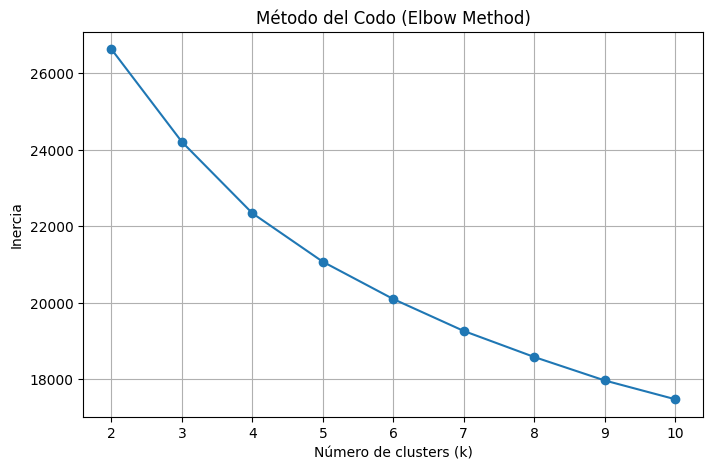

In [52]:
# -------------------------------------------------------------
# 9.1. Método del codo (Elbow Method)
# -------------------------------------------------------------

# Probamos distintos valores de k para ver cuál minimiza la inercia sin sobreajustar. Normalmente entre 2 y 10 es suficiente.

inertias = []
K = range(2, 11)   # probamos k de 2 a 10

for k in K:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(X_cluster)
    inertias.append(kmeans.inertia_)   # guardamos la inercia

# Gráfico del método del codo
plt.figure(figsize=(8,5))
plt.plot(K, inertias, marker='o')
plt.title("Método del Codo (Elbow Method)")
plt.xlabel("Número de clusters (k)")
plt.ylabel("Inercia")
plt.grid(True)
plt.savefig("src/correcciondef/img/elbow_method.png", dpi=300, bbox_inches="tight") # Guardar la figura con alta resolución
plt.show() # Mostrar la figura en pantalla

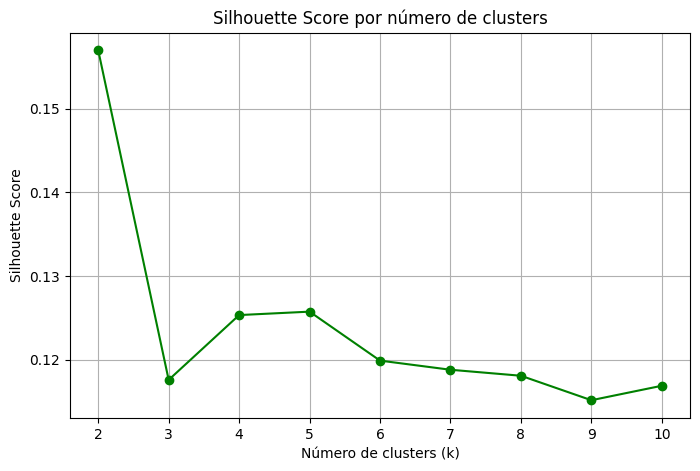

In [53]:
# -------------------------------------------------------------
# 9.2. Silhouette Score para validar k
# -------------------------------------------------------------

# El silhouette mide qué tan separados están los clusters.
# Valores cercanos a 1 indican clusters bien definidos.

sil_scores = []

for k in K:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = kmeans.fit_predict(X_cluster)
    sil_scores.append(silhouette_score(X_cluster, labels))

# Gráfico del silhouette
plt.figure(figsize=(8,5))
plt.plot(K, sil_scores, marker='o', color='green')
plt.title("Silhouette Score por número de clusters")
plt.xlabel("Número de clusters (k)")
plt.ylabel("Silhouette Score")
plt.grid(True)
plt.savefig("src/correcciondef/img/silhouette_scores.png", dpi=300, bbox_inches="tight") # Guardar la figura con alta resolución
plt.show() # Mostrar la figura en pantalla

In [54]:
# -------------------------------------------------------------
# 9.3. Entrenamiento final del modelo KMeans
# -------------------------------------------------------------

# Elegimos el k óptimo según el elbow + silhouette.
# (Se puede ajustar este valor según gráficos)

k_optimo = 2   # según el Silhouette Score (podría ajustarse también a 3 según el elbow)

# Entrenamos el modelo final
kmeans_final = KMeans(n_clusters=k_optimo, random_state=42, n_init=10)
cluster_labels = kmeans_final.fit_predict(X_cluster)

# -------------------------------------------------------------
# Asignar los clusters al TRAIN
# -------------------------------------------------------------

train_feat["Cluster"] = cluster_labels

# -------------------------------------------------------------
# Guardar el modelo entrenado en src/correcciondef/models/
# -------------------------------------------------------------
import joblib
joblib.dump(kmeans_final, "src/correcciondef/models/model_kmeans.pkl")

['src/correcciondef/models/model_kmeans.pkl']

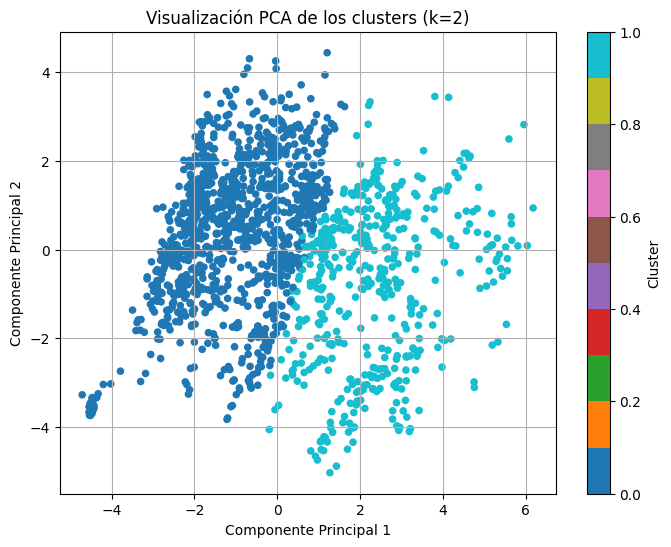

In [55]:
# -------------------------------------------------------------
# 9.4. Visualización 2D con PCA
# -------------------------------------------------------------

# Reducimos de 16 variables a 2 componentes principales para visualizar los clusters en un plano.

pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_cluster)

plt.figure(figsize=(8,6))
plt.scatter(X_pca[:,0], X_pca[:,1], c=cluster_labels, cmap="tab10", s=20)
plt.title(f"Visualización PCA de los clusters (k={k_optimo})")
plt.xlabel("Componente Principal 1")
plt.ylabel("Componente Principal 2")
plt.colorbar(label="Cluster")
plt.grid(True)
plt.savefig("src/correcciondef/img/pca_clusters.png", dpi=300, bbox_inches="tight") # Guardar la figura con alta resolución
plt.show() # Mostrar la figura en pantalla

In [56]:
# -------------------------------------------------------------
# 9.5. Interpretación básica de clusters
# -------------------------------------------------------------

# Calculamos la media de cada feature por cluster
cluster_summary = df_cluster.groupby("cluster")[cols_cluster].mean()

cluster_summary

Contaminante,PM10,PM25,NO2,O3,PM10_cumsum,PM25_cumsum,NO2_cumsum,O3_cumsum,PM10_diff,PM25_diff,NO2_diff,O3_diff,PM10_lag1,PM25_lag1,NO2_lag1,O3_lag1,PM10_roll7,PM25_roll7,NO2_roll7,O3_roll7
cluster,,,,,,,,,,,,,,,,,,,,
0,12.045276,5.715642,14.785113,54.156373,1793.989275,906.787685,2009.670154,5940.905653,0.399327,0.132547,0.061867,-0.177489,11.401995,5.449839,14.465339,53.733517,13.154229,6.429309,15.936926,54.736778
1,18.026248,9.000969,19.732389,59.933365,6301.988882,3099.490510,7745.706292,20711.514045,-0.019464,0.102752,0.608892,0.115088,18.045712,8.898218,19.123497,59.818278,18.617901,8.958037,19.661874,59.728324
2,17.103070,12.563023,28.462971,44.468950,2866.303337,1316.451712,2983.570311,8306.766790,0.427457,-0.311131,-0.209970,0.443634,16.675613,12.874154,28.672941,44.025316,17.427355,11.968985,25.744477,46.998566
3,29.013058,10.158571,14.620180,68.241237,2281.924109,987.423800,2081.903677,6254.284359,-0.936741,0.095357,-0.312572,-0.583388,29.949799,10.063214,14.932752,68.824625,27.230651,9.849017,16.199755,66.249760


In [57]:
# 10. MODELOS DE REGRESIÓN

# En este apartado entrenamos varios modelos para predecir PM10:
#   - Regresión Lineal
#   - Random Forest Regressor
#   - MLPRegressor (red neuronal)

# Evaluamos con: MAE, RMSE, R²

from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.neural_network import MLPRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import matplotlib.pyplot as plt
import numpy as np
import joblib # Para guardar modelos entrenados

In [58]:
# -------------------------------------------------------------
# 10.1. Función auxiliar para evaluar modelos
# -------------------------------------------------------------

# Esta función calcula las métricas más importantes para evaluar un modelo de regresión:
#   - MAE  (Mean Absolute Error)
#   - RMSE (Root Mean Squared Error)
#   - R²   (Coeficiente de determinación)

# Además imprime los resultados de forma clara.

def evaluar_modelo(nombre, y_test, y_pred):
    # Error absoluto medio
    mae = mean_absolute_error(y_test, y_pred)

    # Error cuadrático medio y su raíz
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))

    # Coeficiente de determinación
    r2 = r2_score(y_test, y_pred)

    # Mostrar resultados
    print(f"\n===== {nombre} =====")
    print(f"MAE :  {mae:.4f}")
    print(f"RMSE:  {rmse:.4f}")
    print(f"R²  :  {r2:.4f}")

    # Devolver métricas por si las necesitamos después
    return mae, rmse, r2

In [59]:
# -------------------------------------------------------------
# 10.2. Regresión Lineal
# -------------------------------------------------------------

# Entrenamos un modelo de regresión lineal simple para predecir PM10.
# Este modelo sirve como baseline (modelo base) para comparar con modelos más complejos como Random Forest o MLP.

from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# -------------------------------------------------------------
# Entrenar el modelo
# -------------------------------------------------------------

# Creamos el modelo de regresión lineal
modelo_lr = LinearRegression()

# Entrenamos con TRAIN
modelo_lr.fit(X_train, y_train)

# -------------------------------------------------------------
# Predicción sobre el conjunto de test
# -------------------------------------------------------------

y_pred_lr = modelo_lr.predict(X_test)

# -------------------------------------------------------------
# Evaluación del modelo (usando la función auxiliar)
# -------------------------------------------------------------

# La función imprime las métricas y además devuelve MAE, RMSE y R²,
# que guardamos en variables para compararlas después.

mae_lr, rmse_lr, r2_lr = evaluar_modelo("Regresión Lineal", y_test, y_pred_lr)

# -------------------------------------------------------------
# Guardar el modelo entrenado en src/correcciondef/models/
# -------------------------------------------------------------

joblib.dump(modelo_lr, "src/correcciondef/models/model_regresion_lineal.pkl")


===== Regresión Lineal =====
MAE :  86.4095
RMSE:  209.9277
R²  :  -0.2608


['src/correcciondef/models/model_regresion_lineal.pkl']

In [60]:
# -------------------------------------------------------------
# 10.3. Random Forest Regressor
# -------------------------------------------------------------

modelo_rf = RandomForestRegressor(
    n_estimators=300,
    max_depth=None,
    random_state=42
)

modelo_rf.fit(X_train, y_train)
y_pred_rf = modelo_rf.predict(X_test)

mae_rf, rmse_rf, r2_rf = evaluar_modelo("Random Forest", y_test, y_pred_rf)

# -------------------------------------------------------------
# Guardar el modelo entrenado en src/correcciondef/models/
# -------------------------------------------------------------

joblib.dump(modelo_rf, "src/correcciondef/models/model_random_forest.pkl")



===== Random Forest =====
MAE :  62.7864
RMSE:  194.7536
R²  :  -0.0851


['src/correcciondef/models/model_random_forest.pkl']

In [61]:
# -------------------------------------------------------------
# 10.4. MLPRegressor (Red Neuronal)
# -------------------------------------------------------------

modelo_mlp = MLPRegressor(
    hidden_layer_sizes=(64, 32),
    activation="relu",
    solver="adam",
    max_iter=500,
    random_state=42
)

modelo_mlp.fit(X_train, y_train)
y_pred_mlp = modelo_mlp.predict(X_test)

mae_mlp, rmse_mlp, r2_mlp = evaluar_modelo("MLPRegressor", y_test, y_pred_mlp)

# -------------------------------------------------------------
# Guardar el modelo entrenado en src/correcciondef/models/
# -------------------------------------------------------------

joblib.dump(modelo_mlp, "src/correcciondef/models/model_mlp.pkl")


===== MLPRegressor =====
MAE :  140.7579
RMSE:  297.3912
R²  :  -1.5303


c:\Users\maria\tf_env\lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:781: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (500) reached and the optimization hasn't converged yet.
  warnings.warn(


['src/correcciondef/models/model_mlp.pkl']

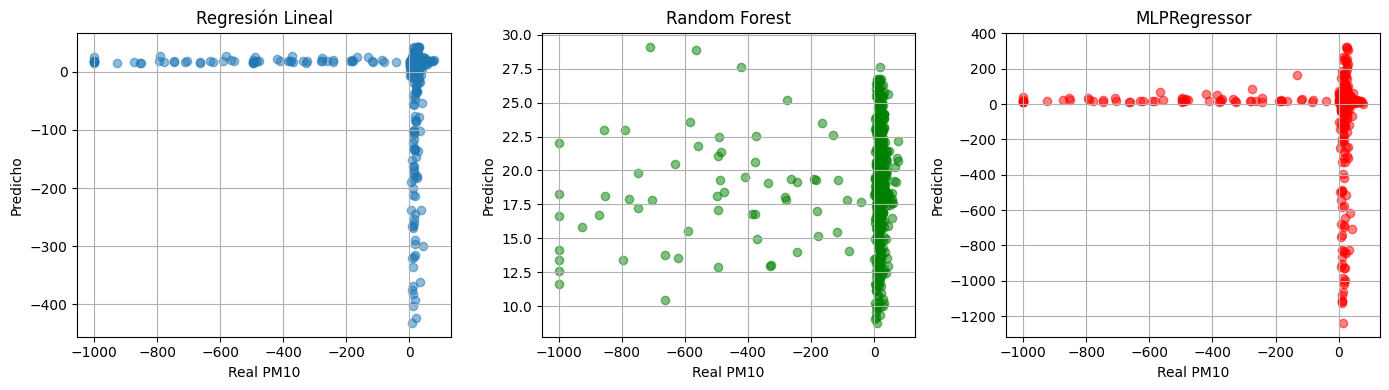

In [62]:
# -------------------------------------------------------------
# 10.5. Gráficas de predicción vs real
# -------------------------------------------------------------

plt.figure(figsize=(14,4))

# Lineal
plt.subplot(1,3,1)
plt.scatter(y_test, y_pred_lr, alpha=0.5)
plt.title("Regresión Lineal")
plt.xlabel("Real PM10")
plt.ylabel("Predicho")
plt.grid(True)

# Random Forest
plt.subplot(1,3,2)
plt.scatter(y_test, y_pred_rf, alpha=0.5, color="green")
plt.title("Random Forest")
plt.xlabel("Real PM10")
plt.ylabel("Predicho")
plt.grid(True)

# MLP
plt.subplot(1,3,3)
plt.scatter(y_test, y_pred_mlp, alpha=0.5, color="red")
plt.title("MLPRegressor")
plt.xlabel("Real PM10")
plt.ylabel("Predicho")
plt.grid(True)

plt.tight_layout()
plt.savefig("src/correcciondef/img/prediccion_vs_real.png", dpi=300, bbox_inches="tight") # Guardar la figura con alta resolución
plt.show() # Mostrar la figura en pantalla

In [63]:
# -------------------------------------------------------------
# 10.6. Comparación final de modelos
# -------------------------------------------------------------

resultados = {
    "Modelo": ["Lineal", "Random Forest", "MLP"],
    "MAE": [mae_lr, mae_rf, mae_mlp],
    "RMSE": [rmse_lr, rmse_rf, rmse_mlp],
    "R2": [r2_lr, r2_rf, r2_mlp]
}

import pandas as pd
df_resultados = pd.DataFrame(resultados)
df_resultados

,Modelo,MAE,RMSE,R2
0,Lineal,86.409530,209.927738,-0.260820
1,Random Forest,62.786381,194.753644,-0.085137
2,MLP,140.757908,297.391241,-1.530288
